In [41]:
from pathlib import Path

import numpy as np
import pandas as pd

import pymc as pm
import pytensor.tensor as pt
import preliz as pz
import xarray as xr

import matplotlib.pyplot as pp
import arviz as az
import arviz_plots as azp
import arviz_stats as azs
import graphviz

In [19]:
PROJ_DIR = Path.cwd().parent
FIG_DIR = PROJ_DIR / 'figures'
DATA_DIR = PROJ_DIR / "data"
SENT_DAT_DIR = DATA_DIR / "sent_data"
PROC_DAT_DIR = SENT_DAT_DIR / "processed"

In [3]:
# --> Load aggregated functioal response data 
# --> This data was used to build figure 2 in Nandini et al (2026)

fr = pd.read_csv(PROC_DAT_DIR / 'hoja1_functional_response.csv')

In [4]:
N_REPLICATES = 4
SAL_LEVELS = [10, 20, 30]
N0   = fr['N0'].to_numpy(float)
ybar = fr['mean_consumed'].to_numpy(float)
se   = fr['se_consumed'].to_numpy(float)
n    = np.full(len(fr), N_REPLICATES, dtype='int32')   
sd_w = se * np.sqrt(n)


In [5]:
prey_idx, prey = pd.factorize(fr['Prey_Type'])
prey_dix = prey_idx.astype('int32')
# Salinity is ordinal, so we'll proceed differently
sal_int = fr['Salinity'].str.extract(r'(\d+)')[0].astype(int)
sal_idx = pd.Categorical(
    sal_int, categories=SAL_LEVELS, ordered=True
    ).codes.astype('int32')

assert (prey_idx >= 0).all(), "NaN/unmapped prey slipped to -1"
assert (sal_idx  >= 0).all(), "salinity label outside {10, 20, 30}"
assert len(prey) == 3, f"expected 3 prey, got {list(prey)}"

coords = {
    "prey": list(prey), 
    "salinity": SAL_LEVELS, 
    "obs": np.arange(len(fr)),
    }

Holling disc equation:
$$\mu =  \frac{a \cdot N}{1+a \cdot h \cdot N}$$
where,
* $a$ is attack rate
* $h$ is handling time
* $N$ is consumption


The data generative process can be represented as follows:

<u>Indexing</u>:
* $i \in {1, 2, 3}$ - prey (Apo, Nito, Bp)
* $j \in {1, 2, 3}$ - salinity (10, 20, 30g/L)
* $k = K_{ij}$ - series of initial prey density offered
* $u$, $v$ - prey (i), salinity (j) main effect, respectively (for $\alpha$ and h)
* $w$ - prey $\times$  salinity interaction (ij) for both $\alpha$ and h
* $\alpha_{ij}$ - attack rate (low-density capture fraction) per cell
* $h_{ij}$ - handling time, per cell
* $N_{0,ijk}$ - offered prey density (data)
* $\mu_{ijk}$ - mean consumption, via $\mu=\frac{\alpha N_0}{1 + \alpha h N_0}$
* A_{ij} = 1 / $h_{ij}$ - asymptote, if you want the maximum-consuption number for reporting

**Cell-level mechanisitic parameters** (one $\alpha_{ij} and one $h_{ij}$ per
preyxsalinity cell - no k dependence since attack rate $\alpha$ and handling time  h
are Holling constants across prey density):

$$logit \alpha_{ij} = a_0 + u_i^a + v_j^a + w_{ij}^a, \ \ \alpha_{ij} = logit^{-1}(\cdot)\in (0,1)$$

$$log h_{ij} = h_0 + u_i^h + v_j^h + w_{ij}^h, \ \ h_{ij} = exp(\cdot) > 0$$

Holling mean; density $k$ enters here and only here:

$$\mu_{ijk} = \frac{\alpha_{ij} \cdot N_{0,ijk}}{1+\alpha_{ij} \cdot h_{ij} \cdot N_{0,ijk}}$$



Likelihood:
$$\bar{y}_{ijk} ~ Gamma(\mu=\mu_{ijk}, \sigma=se_{ijk})$$


## Model M0 — structural baseline (known-SE only)

**Purpose.** M0 fixes the full causal/mechanistic structure and asks only whether it *samples* and recovers biologically sane parameters. Noise around the curve is exactly the reported standard error `se`; no estimated dispersion. It is expected to under-disperse (it asserts the smooth curve passes through every true cell mean) and is a **diagnostic, not a contender**.

### Shared causal skeleton (identical in M0 / M1 / M2 — left panel of the DAG)

- **Design variables, set by the experimenter:** salinity `S`, prey type `P`, prey density `N0`. Because these are intervened on, the DAG has no arrows *into* them: no backdoor paths, so each effect on the parameters and outcome is a clean causal effect by design.
- **Latent Holling parameters:** attack rate `α` (low-density capture fraction) and handling time `h`. These are the mechanistic quantities of the Type II functional response — Holling's disc equation ([Holling 1959](https://doi.org/10.4039/Ent91385-7)). A Type II response is documented in other cnidarians, e.g. the cold-water coral *Desmophyllum dianthus* ([Höfer et al. 2018](https://doi.org/10.7717/peerj.5872)) — which notably showed **non-saturation** at high prey density, mirroring the weak asymptote identifiability we meet here — and the source study reports a Type II response for *C. caspia* itself.

### Why a functional-response model

*C. caspia* is an invasive predator, and comparative functional-response analysis is an established framework for predicting invader impact from attack rate and handling time ([Dick et al. 2014](https://doi.org/10.1007/s10530-013-0550-8)).

### Prey type → α, h (direct morphology effect)

Prey identity sets size, escape speed, and exoskeleton, which govern both capture and processing. *Cordylophora* recognises and captures prey by chemoreception of proline/protease cues, discharging nematocysts ([Fulton 1963](https://doi.org/10.1085/jgp.46.4.823)); larger, faster, or better-armoured prey are captured and handled differently. Small prey size is a documented anti-predator defence that lowers effective attack rate for invertebrate predators (Sarma & Nandini 2007; see Nandini et al. 2026 and refs therein), consistent with rotifers being taken at a lower fraction than copepods.

### Holling assembly and the (0, N0) bound

`μ = α·N0 / (1 + α·h·N0)`: at low density `μ → α·N0` (capture-limited, slope α); at high density `μ → 1/h` (handling-limited asymptote `A`). Since `α ∈ (0,1)` and the denominator ≥ 1, `μ < N0` **by construction**. Note this bounds the *mean* `μ`, not a simulated observation — the gap that M2 addresses.

### Measurement layer (M0)

`ȳ ~ Gamma(μ, se)` — positive support, `E[ȳ] = μ`, with `se` conditioned on as the known measurement scale. One variance only.

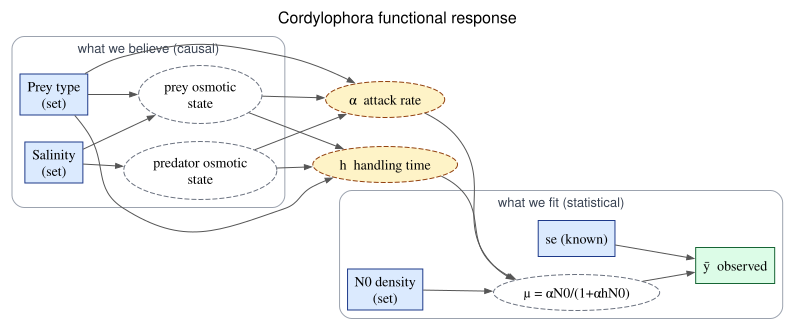

In [ ]:
# McElreath convention: DASHED = unobserved / latent ; SOLID = observed / data.
# Light fills encode ROLE; the border style carries observed-vs-latent.
DESIGN  = dict(shape="box",     style="filled,solid",  fillcolor="#dbeafe", color="#1e3a8a")
OUTCOME = dict(shape="box",     style="filled,solid",  fillcolor="#dcfce7", color="#166534")
PARAM   = dict(shape="ellipse", style="filled,dashed", fillcolor="#fef3c7", color="#92400e")
LATENT  = dict(shape="ellipse", style="dashed",        color="#6b7280")

def _node(g, name, label, kind): g.node(name, label, **kind)

def two_panel_dag(variant="M1", save_name='fig_m1'):
    """One builder, three measurement variants. Causal panel is shared; only the
    model panel's measurement cluster changes (M0=se, M1=sqrt(tau^2+se^2), M2=Beta)."""
    assert variant in {"M0", "M1", "M2"}
    g = graphviz.Digraph(f"fr_dag_{variant}", format="png")
    g.attr(rankdir="LR", fontname="Helvetica", labelloc="t", fontsize="16",
           label=f"Cordylophora functional response")
    g.attr("edge", color="#555555", arrowsize="0.7")

    # ---- Panel 1: causal ("what we believe") ----
    with g.subgraph(name="cluster_causal") as c:
        c.attr(label="what we believe (causal)", style="rounded",
               color="#9ca3af", fontcolor="#374151", fontsize="13")
        _node(c, "S", "Salinity\n(set)", DESIGN)
        _node(c, "P", "Prey type\n(set)", DESIGN)
        _node(c, "Uprey", "prey osmotic\nstate", LATENT)
        _node(c, "Upred", "predator osmotic\nstate", LATENT)
        c.edge("S", "Uprey"); c.edge("S", "Upred"); c.edge("P", "Uprey")

    # ---- bridge: latent Holling parameters ----
    _node(g, "alpha", "α  attack rate", PARAM)
    _node(g, "h",     "h  handling time", PARAM)
    g.edge("P", "alpha"); g.edge("P", "h")                 # direct morphology effect
    g.edge("Uprey", "alpha"); g.edge("Uprey", "h")
    g.edge("Upred", "alpha"); g.edge("Upred", "h")

    # ---- Panel 2: model ("what we fit") ----
    with g.subgraph(name="cluster_model") as m:
        m.attr(label="what we fit (statistical)", style="rounded",
               color="#9ca3af", fontcolor="#374151", fontsize="13")
        _node(m, "N0", "N0 density\n(set)", DESIGN)
        _node(m, "mu", "μ = αN0/(1+αhN0)", LATENT)
        if variant == "M0":
            _node(m, "se", "se (known)", DESIGN)
            _node(m, "y",  "ȳ  observed", OUTCOME)
            m.edge("mu", "y"); m.edge("se", "y")
        elif variant == "M1":
            _node(m, "se",    "se (known)", DESIGN)
            _node(m, "tau",   "τ  process SD", LATENT)
            _node(m, "sigma", "σ_eff = √(τ²+se²)", LATENT)
            _node(m, "y",     "ȳ  observed", OUTCOME)
            m.edge("tau", "sigma"); m.edge("se", "sigma")
            m.edge("mu", "y"); m.edge("sigma", "y")
        else:  # M2
            _node(m, "p",   "p = μ/N0\n(fraction)", LATENT)
            _node(m, "phi", "φ  dispersion", LATENT)
            _node(m, "y",   "ȳ/N0  observed\n(proportion)", OUTCOME)
            m.edge("p", "y"); m.edge("phi", "y")

    g.edge("alpha", "mu"); g.edge("h", "mu"); g.edge("N0", "mu")
    if variant == "M2":
        g.edge("mu", "p"); g.edge("N0", "p")
    
    return g

two_panel_dag("M0")   # renders inline in Jupyter

In [9]:
with pm.Model(coords=coords) as fr_model_m0:
    # Everything that could be swapped at predict-time lives in pm.Data
    N0_     = pm.Data("N0",     N0,     dims="obs")     # predictor AND upper bound
    ybar_   = pm.Data("ybar",   ybar,   dims="obs")     # observed cell mean
    se_     = pm.Data("se",     se,     dims="obs")     # known SE
    pix = pm.Data("prey_idx",  prey_idx,   dims='obs')
    six = pm.Data("sal_idx",    sal_idx,    dims='obs')

    # --- low-density capture fraction alpha, in (0,1) ------------------------
    # BACKGROUND CONSTRAINT (not from this data): consumption cannot exceed prey
    # offered, so the low-density slope consumed/offered is a fraction in (0,1).
    # Hence the LOGIT scale.  NOTE: this bounds mu < N0, NOT the simulated ybar
    # (the Gamma tail is unbounded) -- that ceiling question is what M1 vs M2 test.
    #
    # a0: with ZeroSumNormal effects (sum to 0), the intercept is the GRAND MEAN
    #     logit capture fraction across all cells.
    #     Normal(0, 1.5) => median fraction 0.5, central 95% ~ (0.05, 0.95).
    a0 = pm.Normal('a0', mu=0, sigma=1.5)
    a_prey = pm.ZeroSumNormal('a_prey', sigma=1.0, dims='prey')
    a_sal = pm.ZeroSumNormal('a_sal', sigma=1.0, dims='salinity')
    # interaction: deviation not explained by the two main effects, sum-to-zero on
    # BOTH margins. sigma < main-effect sigma => background lean toward additivity.
    a_int = pm.ZeroSumNormal(
        'a_int', sigma=0.5, dims=('prey', 'salinity'), n_zerosum_axes=2)
    α = pm.Deterministic(
        'α', pm.math.invlogit(a0 + a_prey[pix] + a_sal[six] + a_int[pix, six]),
        dims='obs'
    )

    # handling time h > 0 -> log scale. Same (prey, salinity, interaction)
    # structure as the attack rate; priors background-only and tighter than a's.
    h0 = pm.Normal('h0', np.log(1/40), 0.75) # grand-mean log handling time
    h_prey = pm.ZeroSumNormal('h_prey', sigma=0.5, dims='prey')
    h_sal = pm.ZeroSumNormal('h_sal', sigma=0.5, dims='salinity')
    h_int = pm.ZeroSumNormal(
        'h_int', sigma=0.3, dims=('prey', 'salinity'), n_zerosum_axes=2)
    h = pm.Deterministic(
        'h', pt.exp(h0 + h_prey[pix] + h_sal[six] + h_int[pix, six]),
        dims='obs'
        )
    pm.Deterministic('A', 1.0/h, dims='obs') # asymptote, per cell.

    # --- Holling type II disc equation, native (attack rate, handling time) form ---
    μ = pm.Deterministic('μ', α * N0_ / (1+ α * h * N0_), dims='obs')

    # --- Measurement model: KNOWN SE only, no estimated dispersion -------------
    # M0 baseline: noise around the curve is exactly the reported se. No tau.
    # Purpose is to confirm the STRUCTURE samples and recovers sane alpha/h
    # before adding the process-variance (M1) or bounded-support (M2) layers.
    pm.Gamma('likelihood', mu=μ, sigma=se_, observed=ybar_, dims='obs')

## Model M1 — two-variance measurement error (process + measurement)

**What changes from M0: only the measurement layer.** M0's single known `se` asserts the smooth Holling curve passes exactly through every *true* cell mean. M1 restores the process/lack-of-fit term that measurement-error models carry: a true value scatters around the structural prediction (process SD `τ`, estimated), and the observation scatters around the true value (measurement SD, the known `se`). Marginalising the latent true mean over Gaussians gives the quadrature `σ_eff = √(τ² + se²)` — so `τ` is the process σ and `se` the known measurement S ([McElreath 2023, PyMC port, Lecture 17](https://www.pymc.io/projects/examples/en/latest/statistical_rethinking_lectures/17-Measurement_and_Misclassification.html)).

### Salinity → α and h (via unobserved osmotic states)

M1 is where the salinity structure does its work, so the arrows are justified explicitly:

- **S → predator state → α, h.** Salinity gates the capture apparatus directly: *C. caspia* nematocysts cease to function in freshwater and its feeding reaction is salinity-dependent ([Fulton 1963](https://doi.org/10.1085/jgp.46.4.823)). Salinity also imposes osmotic stress on the hydroid at the tissue/cellular level — cell shrinkage/lysis, volume-regulation cost — altering growth and hydranth morphology ([Folino-Rorem & Renken 2018](https://doi.org/10.1111/ivb.12207)). A stressed or morphologically altered polyp plausibly captures (α) and processes (h) prey differently.
- **S → prey state → α, h.** Salinity osmotically stresses the euryhaline prey too, changing rigidity/behaviour and thus catchability and subdual time. Because the tested prey tolerate 10–30 g/L, this prey-side effect is expected to be **modest** — one reason h's priors are deliberately tighter.
- **Unobserved mediators ⇒ total effect only.** Both osmotic-state nodes are unmeasured, so the model estimates the **total** salinity effect on α and h; it cannot separate prey-mediated from predator-mediated routes. Stated limitation, not a bug.

### Prey × salinity interaction

Prey type and salinity share the prey-osmotic-state child, so their effects on α and h are non-additive by construction. This is not mere speculation: the source ANOVA found a **significant salinity × prey interaction on prey numbers** (Nandini et al. 2026, Table 2: salinity p = 0.036, prey p = 0.006, interaction p = 0.018).

### A literature tension we address rather than hide

The source paper's narrative concludes "salinities ranging from 10 to 30 g/L had no effect on the predator's feeding behavior," and its *biomass* ANOVA shows no salinity main effect (p = 0.256) or interaction (p = 0.650). At face value that argues against routing salinity into α and h. We proceed for four reasons:

1. **The tension is with the biomass/summary framing, not the counts.** The same study's *numbers* ANOVA shows significant salinity and salinity×prey effects (Table 2, above). Our response is counts, so salinity structure is consistent with the data's own count-level result.
2. **Causal structure is set by mechanism, then regularised by priors — not pruned by data.** A path that plausibly generates the data belongs in the graph; the data update it (McElreath, Lecture 17). Deleting salinity because one ANOVA was non-significant would let a null dictate the causal model.
3. **A non-significant frequentist effect is not zero.** The model returns a posterior per salinity contrast with honest uncertainty; where the data are uninformative (especially for h/asymptote), power-scaling sensitivity (`psense`) will flag the effect as prior-driven rather than silently assuming it away.
4. **Euryhaline biology predicts small, not absent.** Predator and prey both tolerate the tested range, so we *expect* modest effects — encoded as tighter h priors, not a deleted path.

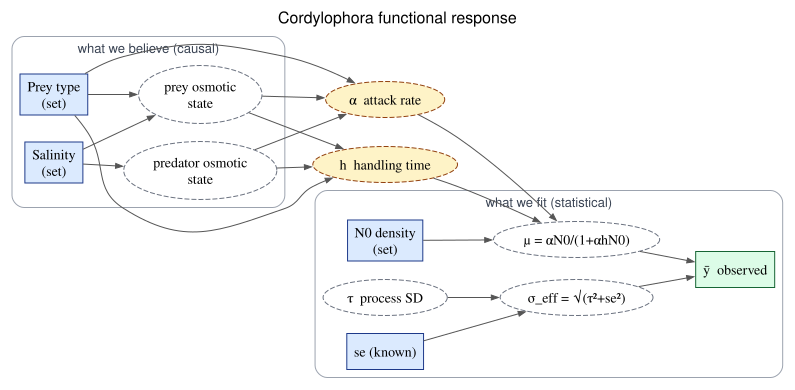

In [20]:
two_panel_dag("M1")   # same builder; McElreath two-variance measurement layer

In [23]:
two_panel_dag("M1").render(FIG_DIR/'m1_dag', format="pdf", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m1_dag.pdf'

In [24]:
two_panel_dag("M1").render(FIG_DIR/'m1_dag', format="png", cleanup=True)

'/Users/erdemkarakoylu/projex/replications/nandini_et_al/figures/m1_dag.png'

In [13]:
with pm.Model(coords=coords) as fr_model:
    # Everything that could be swapped at predict-time lives in pm.Data
    N0_     = pm.Data("N0",     N0,     dims="obs")     # predictor AND upper bound
    ybar_   = pm.Data("ybar",   ybar,   dims="obs")     # observed cell mean
    se_     = pm.Data("se",     se,     dims="obs")     # known SE (plain version)
    pix = pm.Data("prey_idx",  prey_idx,   dims='obs')
    six = pm.Data("sal_idx",    sal_idx,    dims='obs')  

    # --- low-density capture fraction alpha, in (0,1) ------------------------
    # BACKGROUND CONSTRAINT (not from this data): consumption cannot exceed prey
    # offered, so the low-density slope consumed/offered is a fraction in (0,1).
    # Hence the LOGIT scale; invlogit also forces mu < N0 by construction.
    #
    # a0: with ZeroSumNormal effects (sum to 0), the intercept is the GRAND MEAN
    #     logit capture fraction across all cells.
    #     Normal(0, 1.5) => median fraction 0.5, central 95% ~ (0.05, 0.95):
    #     an ignorance prior on a bounded fraction, symmetric, pre-data.

    a0 = pm.Normal('a0', mu=0, sigma=1.5)
    a_prey = pm.ZeroSumNormal('a_prey', sigma=1.0, dims='prey')
    a_sal = pm.ZeroSumNormal('a_sal', sigma=1.0, dims='salinity')
    # interaction: devaiation not explained by the two main effects
    # sum-to-zero on BOTH margins(n_zerosum_axes=2). Has a sigma lower 
    # than the main-effect sigma, it encodes a background lean toward 
    # additivity. This because interaction is a correction, expected to be
    # the smaller term until the data says otherwise.
    a_int = pm.ZeroSumNormal(
        'a_int', sigma=0.5, dims=('prey', 'salinity'), n_zerosum_axes=2)
    α = pm.Deterministic(
        'α', pm.math.invlogit(a0 + a_prey[pix] + a_sal[six] + a_int[pix, six]),
        dims='obs'
    )

    # handling time h > 0 -> log scale. Same (prey, salinity, interaction)
    # structure as the attack rate, because the DAG routes BOTH parameters
    # through the same prey/predator osmotic states: whatever lets salinity and
    # prey-identity (and their interaction) move a, moves h too.
    # Priors are background-only and DELIBERATELY TIGHTER than a's.  Rationale is:
    #(i) this is a euryhaline species whose tested 10-30 g/L sits inside its 
    # 5-40 tolerance, so handling shifts are expected to be modest; 
    # (ii) the asymptote (1/h) is structurally weakly identified by 
    # sub-saturating curves, so we lean on background and will let psense 
    # report which h-effects are prior-driven rather than data-driven.
    h0 = pm.Normal('h0', np.log(1/40), 0.75) # grand-mean log handling time
    h_prey = pm.ZeroSumNormal('h_prey', sigma=0.5, dims='prey')
    h_sal = pm.ZeroSumNormal('h_sal', sigma=0.5, dims='salinity')
    h_int = pm.ZeroSumNormal(
        'h_int', sigma=0.3, dims=('prey', 'salinity'), n_zerosum_axes=2)
    h = pm.Deterministic(
        'h', pt.exp(h0 + h_prey[pix] + h_sal[six] + h_int[pix, six]),
        dims='obs'
        ) 
    pm.Deterministic('A', 1.0/h, dims='obs') # asymptote, per cell.

    # --- Holling type II disc equation, native (attack rate, handling time) form ---
    μ = pm.Deterministic('μ', α * N0_ / (1+ α * h * N0_), dims='obs')
    τ = pm.Gamma("τ", alpha=2.0, beta=1.0)
    σ_eff = pm.Deterministic('σ_eff', pt.sqrt(τ**2 + se_**2), dims='obs')

    pm.Gamma('likelihood', mu=μ, sigma=σ_eff, observed=ybar_, dims='obs')

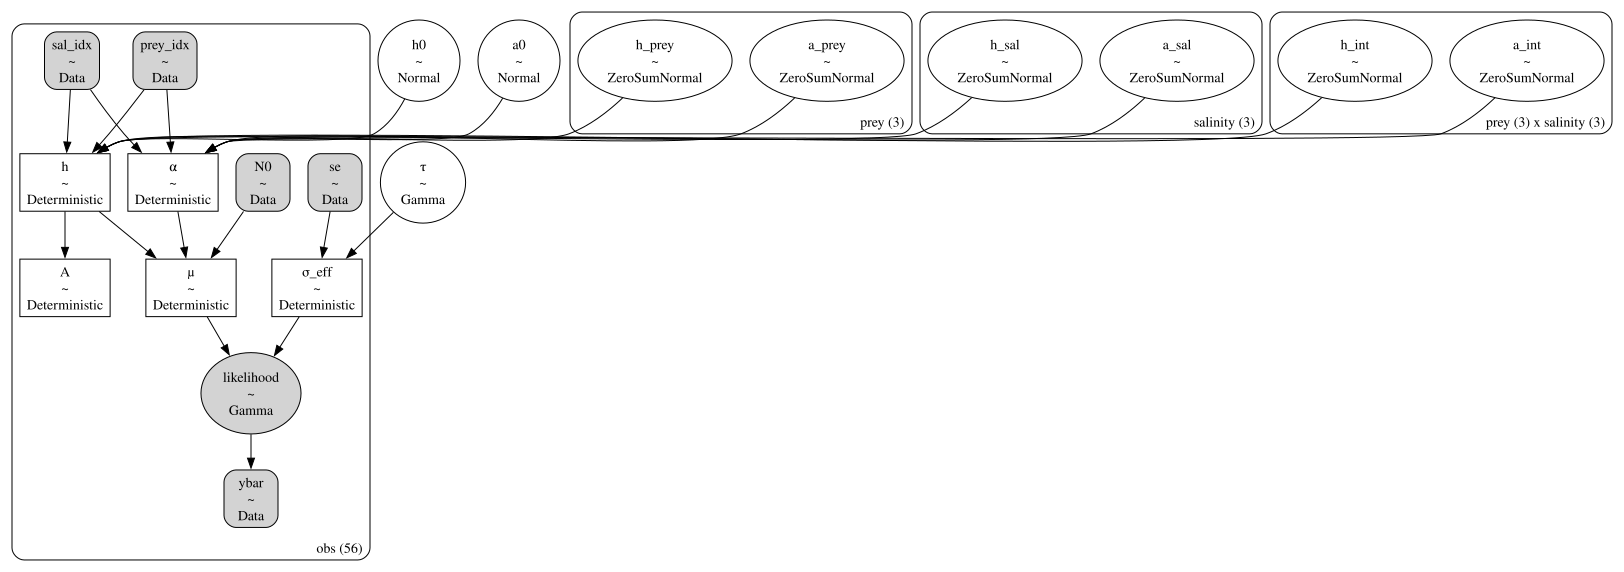

In [14]:
fr_model.to_graphviz()

In [15]:
fr_model.debug()

point={'a0': array(0.), 'a_prey_zerosum__': array([0., 0.]), 'a_sal_zerosum__': array([0., 0.]), 'a_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'h0': array(-3.68887945), 'h_prey_zerosum__': array([0., 0.]), 'h_sal_zerosum__': array([0., 0.]), 'h_int_zerosum__': array([[0., 0.],
       [0., 0.]]), 'τ_log__': array(0.69314718)}

No problems found


In [16]:
with fr_model:
    idata = pm.sample_prior_predictive()

Sampling: [a0, a_int, a_prey, a_sal, h0, h_int, h_prey, h_sal, likelihood, τ]


## 2.4 Prior elicitation

Priors are elicited on **interpretable quantities** — capture fractions, maximum consumption, fold-differences between levels — never on coefficient scales, where no one holds intuitions. Each claim is stated as an interval with a probability, and the **maximum-entropy** distribution consistent with that claim is adopted (least-committal given the stated information; PreliZ `maxent`). Every prior is then **audited in outcome space** (a capture fraction via `invlogit`, an asymptote via `exp` then `1/h`) to confirm the claim we wrote is the claim we encoded.

Two devices make effect priors defensible:

- **Fold-change → σ identity.** For a `ZeroSumNormal(σ)`, any pairwise contrast between levels has SD `σ√2` (exactly, for any number of levels). So a pre-data belief "two levels differ up to *R*-fold" maps directly to `σ = ln(R) / (1.96·√2)`. The reviewer argues with *R*, a biological fold-change — not with a sigma.
- **Differentiated salinity vs. prey widths.** Salinity effects are given *tighter* priors than prey effects on both parameters, because the euryhaline literature does real work here: *C. caspia* and all three prey tolerate 5–40 g L⁻¹ (Folino-Rorem & Renken 2018; Nandini et al. 2026), and the experiment sits at 10–30 g L⁻¹ — well inside tolerance. A priori we therefore expect salinity to shift capture and handling *less* than prey identity does. This is an explicit, citable commitment, and its influence on every reported conclusion is quantified post-fit by power-scaling sensitivity (`psense`).

Two priors are deliberately **not** literature-anchored, and we say why:

- **`a0` (grand-mean capture fraction) is elicited from ignorance, not literature.** No study reports a single "capture fraction" for this predator, and inventing one would be false precision. We instead encode symmetry and boundedness only: median fraction 0.5, 95% within (0.05, 0.95) — the maximum-entropy statement of "it is a fraction and could be anywhere." Letting the data locate it is the honest posture.
- **`h0` (grand-mean handling time) is anchored to a transparent heuristic, not tightened on a related study.** Handling a small zooplankter takes on the order of minutes; over a 2-h assay this caps processing at tens of prey (≈40). The nearest related-cnidarian datum — *Hydra* preying on cladocerans (Rivera-De la Parra et al. 2016) — is only loosely commensurate (solitary freshwater polyp, cladoceran prey, demographic rather than functional-response measurement), so it corroborates the order of magnitude but does **not** justify a narrow prior. `h0` is therefore kept deliberately broad and validated downstream by the prior predictive on implied prey consumption, not by tightening.

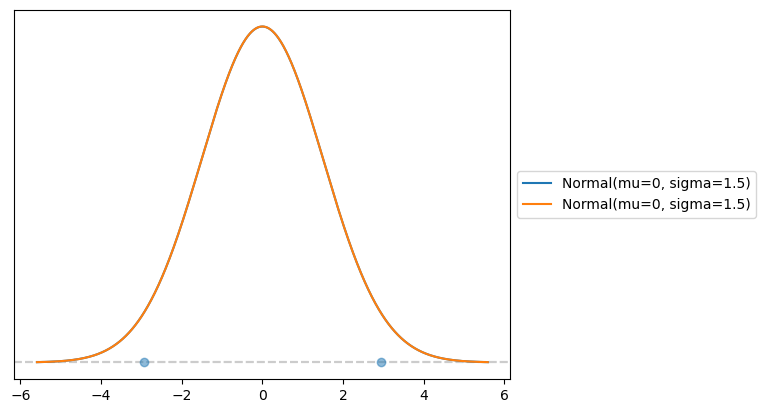

In [ ]:
from scipy.special import expit                      # invlogit for outcome-space audits
# fold-change -> ZeroSumNormal sigma  (contrast SD = sigma*sqrt(2))
zsn_sigma = lambda R: np.log(R) / (1.96 * np.sqrt(2))

# --- a0: grand-mean capture fraction, elicited from IGNORANCE ----------------
# Claim: it is a fraction; median 0.5; 95% within (0.05, 0.95); symmetric.
a0_prior = pz.maxent(pz.Normal(mu=0), np.log(0.05/0.95), np.log(0.95/0.05), 0.95)
# -> Normal(0, 1.50).  AUDIT in outcome space (fraction):
pz.Normal(0, 1.502).plot_pdf()          # then mentally invlogit: mass fills (0,1), peaks mid

# --- a_prey: prey identity moves capture the MOST -----------------------------
# Claim: two prey can differ up to ~7x in capture ODDS (size, escape, armor;
#        Fulton 1963, nematocyst capture of chemically-recognized prey).
a_prey_sigma = zsn_sigma(7)             # -> 0.70

# --- a_sal: salinity moves capture LESS (euryhaline, in-range) -----------------
# Claim: salinity shifts capture odds up to ~3x across 10-30 g/L
#        (tolerance 5-40; Folino-Rorem & Renken 2018).
a_sal_sigma = zsn_sigma(3)              # -> 0.40

# --- a_int: interaction is a second-order correction --------------------------
a_int_sigma = 0.5 * a_prey_sigma        # -> 0.35  (background lean toward additivity)


In [29]:
print(f"a0     ~ Normal(0, {a0_prior.sigma:.2f})")
print(f"a_prey ~ ZSN({a_prey_sigma:.2f})  |  a_sal ~ ZSN({a_sal_sigma:.2f})  |  a_int ~ ZSN({a_int_sigma:.2f})")

# AUDIT: does the a_prey claim really imply ~7x contrasts? simulate the contrast
c = np.random.default_rng(0).normal(0, a_prey_sigma*np.sqrt(2), 40000)   # level-vs-level
print(f"a_prey implied 95% capture-odds ratio: {np.exp(np.percentile(c,97.5)):.1f}x")  # ~7

AttributeError: 'tuple' object has no attribute 'sigma'

In [17]:
pp = idata.prior_predictive["likelihood"]        # (chain, draw, obs)
N0 = idata.constant_data["N0"]                    # (obs,)

# 1) STRUCTURAL: every simulated consumption must lie in (0, N0).
#    This tests the logit+log construction, not the priors. Must be exactly 0.
over  = (pp > N0).mean().item()
under = (pp < 0).mean().item()
print(f"P(sim > N0) = {over:.4f}   P(sim < 0) = {under:.4f}")

# 2) BIOLOGICAL: implied asymptote A = 1/h should be tens of prey, not millions.
A = idata.prior["A"]
print("A (1/h) quantiles 1/50/99:", np.round(A.quantile([.01,.5,.99]).values, 1))

# while you're here, the attack rate shouldn't pile at the bounds:
a = idata.prior["α"]
print("α quantiles 1/50/99:", np.round(a.quantile([.01,.5,.99]).values, 3))

P(sim > N0) = 0.0219   P(sim < 0) = 0.0000
A (1/h) quantiles 1/50/99: [  4.1  39.3 394.6]
α quantiles 1/50/99: [0.013 0.497 0.986]


In [30]:
with fr_model:
    idata = pm.sample(draws=2000)

/Users/erdemkarakoylu/miniconda3/envs/causal_marine/lib/python3.13/site-packages/arviz/__init__.py:110: MigrationWarning: arviz.InferenceData is no longer available on the arviz package; ArviZ now uses xarray's DataTree for the same role. See the migration guide: https://python.arviz.org/en/latest/user_guide/migration_guide.html#datatree
  warnings.warn(
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_40300/4072504765.py:2: UserWarning: pymc requires nutpie>=0.16.10. Falling back to the pymc NUTS sampler. Upgrade with `pip install -U nutpie` or `conda install -c conda-forge 'nutpie>=0.16.10'`.
  idata = pm.sample(draws=2000)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0, a_prey, a_sal, a_int, h0, h_prey, h_sal, h_int, τ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.


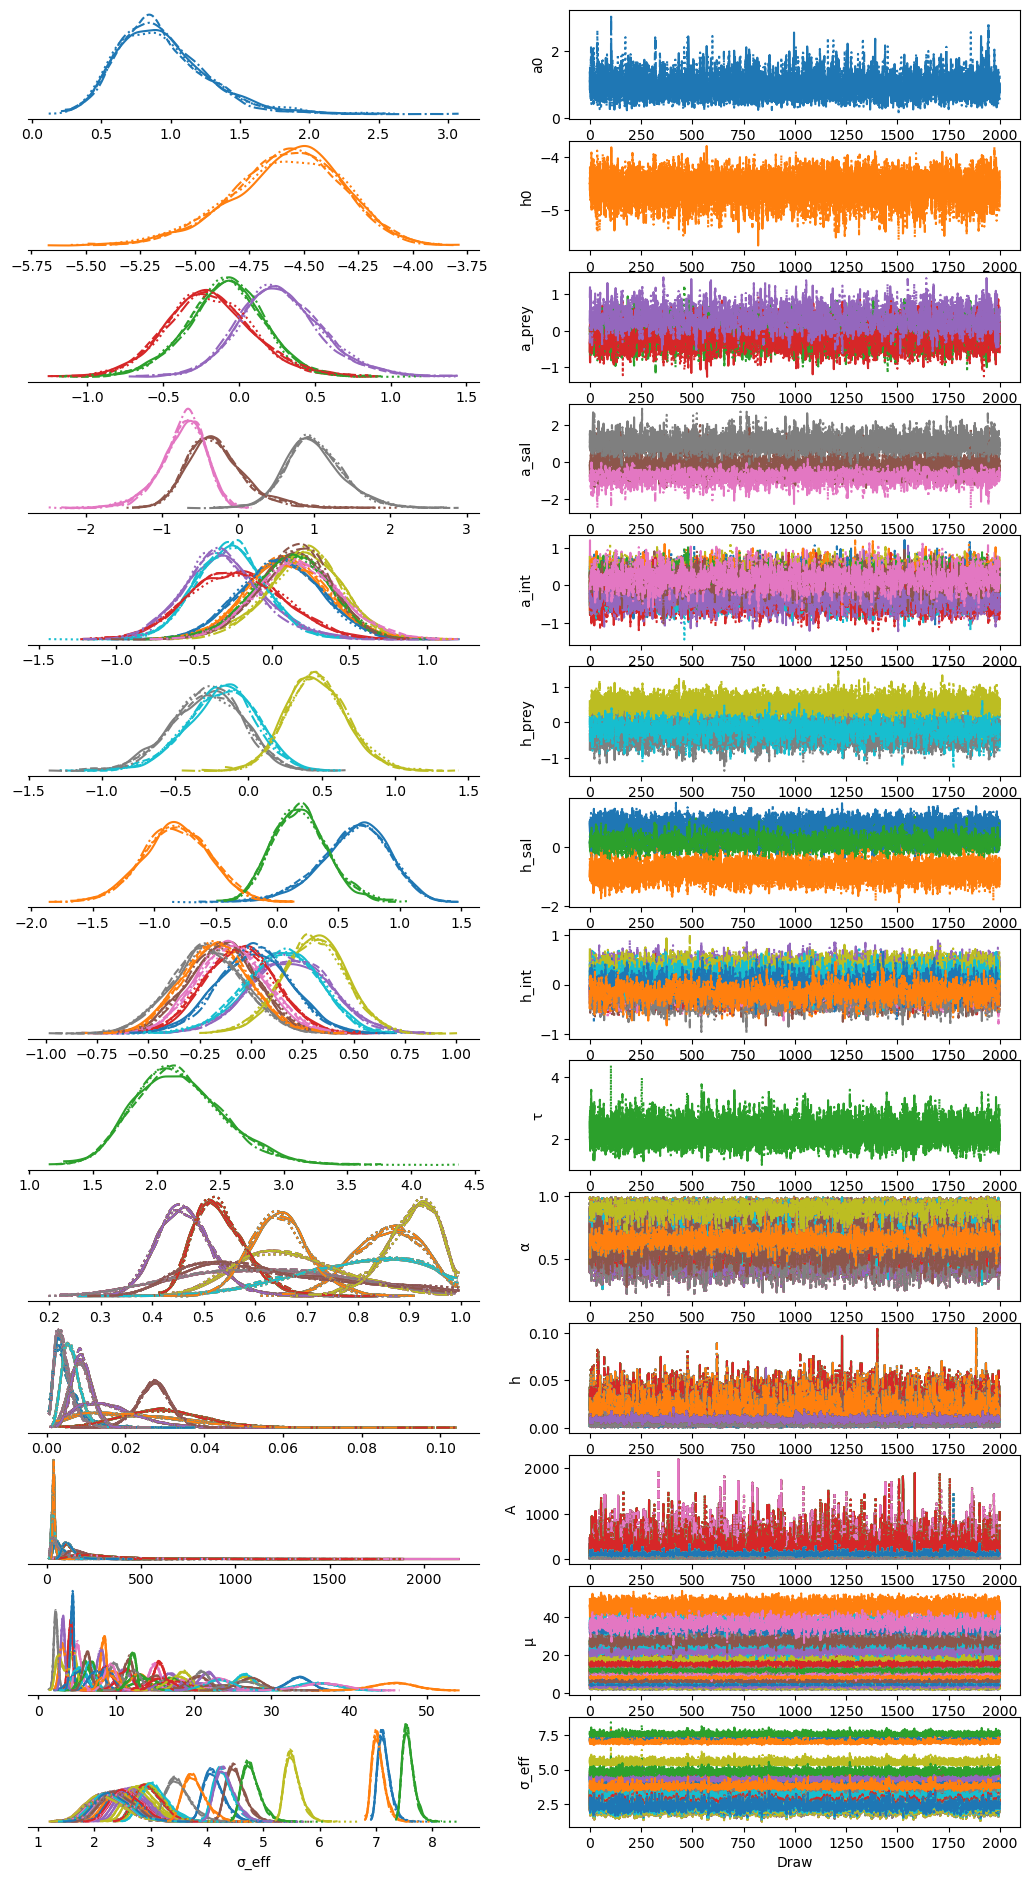

In [31]:
azp.plot_trace_dist(idata)

In [33]:
def verdict(contrast, rope, prob=0.94):
    """contrast: a posterior DataArray with (chain, draw) dims still on it."""
    hdi = azs.hdi(contrast, prob=prob)          # returns a Dataset/DataArray, dims labeled
    s = contrast.stack(z=("chain", "draw")).values
    return dict(mean=float(contrast.mean().values),
                hdi=(float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))),
                p_gt0=float((s > 0).mean()),
                p_in_rope=float((np.abs(s) < rope).mean()))

In [36]:
print(idata)                      # sanity check: posterior group, var names, dims
print(list(idata.posterior.data_vars))

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 2000, prey: 3, salinity: 3, obs: 56)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│         * prey      (prey) <U4 48B 'Apo' 'Bp' 'Nito'
│         * salinity  (salinity) int64 24B 10 20 30
│         * obs       (obs) int64 448B 0 1 2 3 4 5 6 7 8 ... 47 48 49 50 51 52 53 54 55
│       Data variables: (12/14)
│           a0        (chain, draw) float64 64kB 1.357 1.032 1.044 ... 0.7511 0.8701
│           h0        (chain, draw) float64 64kB -4.497 -4.493 -4.442 ... -4.518 -4.948
│           a_prey    (chain, draw, prey) float64 192kB -0.5792 -0.3419 ... -0.06242
│           a_sal     (chain, draw, salinity) float64 192kB -0.1409 -0.9503 ... 1.288
│           a_int     (chain, draw, prey, salinity) float64 576kB 0.4324 ... 0.03112
│           h_prey    (chain, draw, prey) float64 192kB -0.761

In [ ]:
ok, diag = azs.diagnose(idata, return_diagnostics=True, show_diagnostics=False)
print(ok)
print(diag)

### Nandini et al's claims:

1. Copepods eaten more than rotifers
2. Nitokra (harpacticoid) preferred over Apocyclops (cyclopoid)
3. Salinity makes no real difference (over the tested range)
4. Prey and salinity interact.

In [38]:
post = idata.posterior

attack_rate = 1 / (
    1 + np.exp(
        -(post["a0"] + post["a_prey"] + post["a_sal"] + post["a_int"]))
        )
handling_time = np.exp(post["h0"] + post["h_prey"] + post["h_sal"] + post["h_int"])

In [40]:
def eaten(n_offered):
    return attack_rate * n_offered / (1 + attack_rate * handling_time * n_offered)

def compare(a, b, label, prob=0.94):
    diff = a - b                              # keep as DataArray with (chain, draw) dims
    hdi = azs.hdi(diff, prob=prob)
    lo, hi = float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))
    p_gt = float((diff.stack(z=("chain","draw")) > 0).mean())
    print(f"{label:40s} mean={float(diff.mean()):+.3f}  {int(prob*100)}% HDI=[{lo:+.3f}, {hi:+.3f}]  P(a>b)={p_gt:.2f}")

for p1, p2 in [("Nito","Apo"), ("Nito","Bp"), ("Apo","Bp")]:
    compare(attack_rate.sel(prey=p1).mean("salinity"),
            attack_rate.sel(prey=p2).mean("salinity"),
            f"{p1} vs {p2} (alpha)")

Nito vs Apo (alpha)                      mean=+0.062  94% HDI=[-0.070, +0.190]  P(a>b)=0.82
Nito vs Bp (alpha)                       mean=+0.078  94% HDI=[-0.078, +0.237]  P(a>b)=0.82
Apo vs Bp (alpha)                        mean=+0.016  94% HDI=[-0.138, +0.170]  P(a>b)=0.57


In [53]:
pieces = {
    "Nito - Apo":   (attack_rate.sel(prey="Nito") - attack_rate.sel(prey="Apo")).mean("salinity"),
    "Nito - Bp":    (attack_rate.sel(prey="Nito") - attack_rate.sel(prey="Bp")).mean("salinity"),
    "Apo - Bp":     (attack_rate.sel(prey="Apo")  - attack_rate.sel(prey="Bp")).mean("salinity"),
    "sal 10 - 30":  (attack_rate.sel(salinity=10) - attack_rate.sel(salinity=30)).mean("prey"),
    "sal 10 - 20":  (attack_rate.sel(salinity=10) - attack_rate.sel(salinity=20)).mean("prey"),
    "sal 20 - 30":  (attack_rate.sel(salinity=20) - attack_rate.sel(salinity=30)).mean("prey"),
}

contrasts = xr.concat(list(pieces.values()), dim=xr.DataArray(list(pieces.keys()), dims="contrast", name="contrast"))
contrasts = contrasts.to_dataset(name="Δ attack rate")
print(contrasts.coords["contrast"].values)   # confirm: array(['Nito - Apo', 'Nito - Bp', ...])


['Nito - Apo' 'Nito - Bp' 'Apo - Bp' 'sal 10 - 30' 'sal 10 - 20'
 'sal 20 - 30']


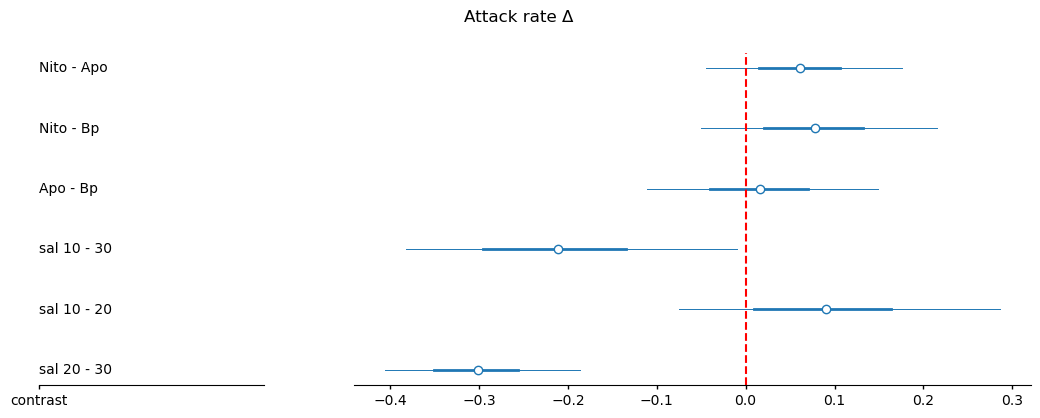

In [71]:
pc = azp.plot_forest(contrasts, var_names=["Δ attack rate"], combined=True, labels=["contrast"])
pp.axvline(0, color='r', ls='--')
pc.add_title("Attack rate Δ")

In [58]:
h_pieces = {
    "Nito - Apo (h)":  (handling_time.sel(prey="Nito") - handling_time.sel(prey="Apo")).mean("salinity"),
    "Nito - Bp (h)":   (handling_time.sel(prey="Nito") - handling_time.sel(prey="Bp")).mean("salinity"),
    "Apo - Bp (h)":    (handling_time.sel(prey="Apo")  - handling_time.sel(prey="Bp")).mean("salinity"),
    "sal 10 - 20 (h)": (handling_time.sel(salinity=10) - handling_time.sel(salinity=20)).mean("prey"),
    "sal 20 - 30 (h)": (handling_time.sel(salinity=20) - handling_time.sel(salinity=30)).mean("prey"),
    "sal 10 - 30 (h)": (handling_time.sel(salinity=10) - handling_time.sel(salinity=30)).mean("prey"),
}

for label, d in h_pieces.items():
    hdi = azs.hdi(d, prob=0.94)
    lo, hi = float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))
    p = float((d.stack(z=("chain","draw")) > 0).mean())
    print(f"{label:20s} mean={float(d.mean()):+.4f}  94% HDI=[{lo:+.4f}, {hi:+.4f}]  P(>0)={p:.2f}")


ratio_pieces = {
    "Nito / Apo (h ratio)": (handling_time.sel(prey="Nito") / handling_time.sel(prey="Apo")).mean("salinity"),
    "Nito / Bp (h ratio)":  (handling_time.sel(prey="Nito") / handling_time.sel(prey="Bp")).mean("salinity"),
    "Apo / Bp (h ratio)":   (handling_time.sel(prey="Apo")  / handling_time.sel(prey="Bp")).mean("salinity"),
    "sal 10/20 (h ratio)":  (handling_time.sel(salinity=10) / handling_time.sel(salinity=20)).mean("prey"),
    "sal 20/30 (h ratio)":  (handling_time.sel(salinity=20) / handling_time.sel(salinity=30)).mean("prey"),
    "sal 10/30 (h ratio)":  (handling_time.sel(salinity=10) / handling_time.sel(salinity=30)).mean("prey"),
}
for label, d in ratio_pieces.items():
    hdi = azs.hdi(d, prob=0.94)
    lo, hi = float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))
    p = float((d.stack(z=("chain","draw")) > 1).mean())   # >1 is the "effect" direction for a ratio
    print(f"{label:20s} mean={float(d.mean()):.3f}  94% HDI=[{lo:.3f}, {hi:.3f}]  P(>1)={p:.2f}")

Nito - Apo (h)       mean=+0.0022  94% HDI=[-0.0063, +0.0116]  P(>0)=0.66
Nito - Bp (h)        mean=-0.0092  94% HDI=[-0.0187, +0.0005]  P(>0)=0.04
Apo - Bp (h)         mean=-0.0114  94% HDI=[-0.0198, -0.0022]  P(>0)=0.01
sal 10 - 20 (h)      mean=+0.0174  94% HDI=[+0.0032, +0.0329]  P(>0)=1.00
sal 20 - 30 (h)      mean=-0.0098  94% HDI=[-0.0150, -0.0044]  P(>0)=0.00
sal 10 - 30 (h)      mean=+0.0077  94% HDI=[-0.0077, +0.0226]  P(>0)=0.82
Nito / Apo (h ratio) mean=1.287  94% HDI=[0.359, 2.343]  P(>1)=0.64
Nito / Bp (h ratio)  mean=0.616  94% HDI=[0.210, 1.052]  P(>1)=0.07
Apo / Bp (h ratio)   mean=0.571  94% HDI=[0.194, 1.026]  P(>1)=0.06
sal 10/20 (h ratio)  mean=5.127  94% HDI=[1.201, 9.921]  P(>1)=1.00
sal 20/30 (h ratio)  mean=0.447  94% HDI=[0.128, 0.825]  P(>1)=0.02
sal 10/30 (h ratio)  mean=1.849  94% HDI=[0.484, 3.235]  P(>1)=0.87


In [65]:
h_contrasts = xr.concat(
    list(ratio_pieces.values()),
    dim=xr.DataArray(list(ratio_pieces.keys()), dims="contrast", name="contrast")
).to_dataset(name="handling time ratio")

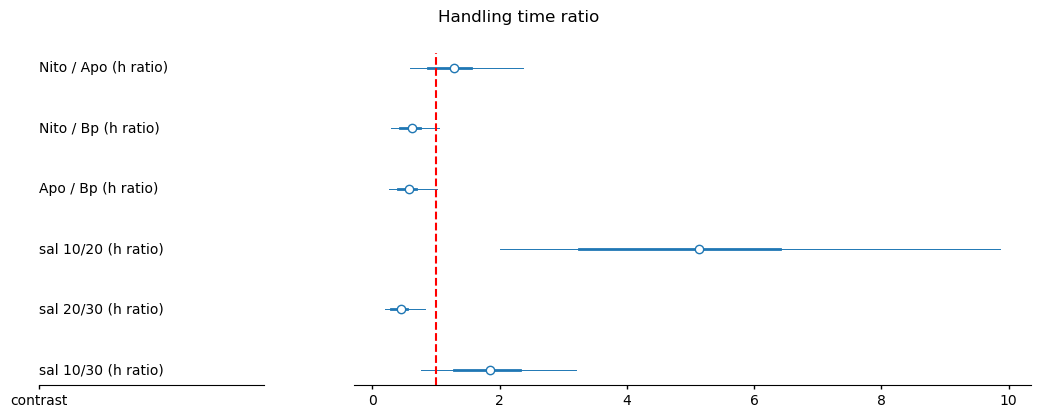

In [68]:
pc = azp.plot_forest(h_contrasts, var_names=["handling time ratio"], combined=True,
                     labels=["contrast"])   # only label the contrast dim, drop var name
pc.add_title(r'Handling time ratio')
pp.axvline(1, ls='--', color='r')

## Model M2 — bounded-support measurement (proportion consumed)

**What changes: the likelihood moves onto the bounded scale.** The prior-predictive check on M1 showed ~2% of simulated cell means exceeding `N0` — impossible, because the Gamma tail is unbounded even though `μ < N0`. M2 removes that by modelling the *fraction* consumed, `ȳ/N0 ~ Beta(mean = μ/N0, dispersion φ)`, so "cannot consume more than offered" holds for the **observation**, not just the mean.

### Why the bound is physically exact here

The response is prey *removed* — initial minus final counts, i.e. prey killed. A predator cannot kill more prey than were offered, so killed/offered ∈ (0,1) is a hard logical bound, not an approximation. *C. caspia* is a **surplus killer** — it kills more than it ingests (Nandini et al. 2026) — but killed still cannot exceed offered, so (0, N0) remains the correct ceiling for this response.

### The cost, stated plainly

M2 buys the hard bound at the price of the clean measurement-error semantics of M1. A Beta on the proportion is **not** the convolution of a process Gaussian and a measurement Gaussian, so `τ` loses its "process SD" meaning and `se` must be repurposed into a Beta dispersion rather than entering as the known measurement SD. M1 and M2 therefore encode genuinely different generative stories on different scales — which is why they are compared by **LOO-CV** (predictive accuracy on held-out cells), *not* by prior sensitivity, and why we inspect whether the prey/salinity effects on α actually differ between them. If they don't, the ceiling leak is cosmetic and M1 is reported with a noted limitation; if they do, that divergence is itself a finding.

### No ecological contradiction

The causal (left) panel is unchanged from M0/M1 — M2 only swaps the statistical observation model — so no new literature justification is needed beyond what M0/M1 establish. The choice is statistical (support and semantics), not biological.

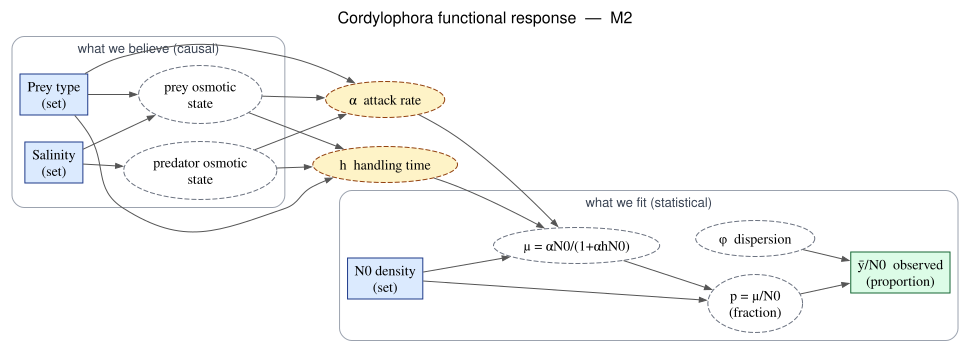

In [8]:
two_panel_dag("M2")   # same builder; bounded proportion (Beta) measurement layer